<a href="https://colab.research.google.com/github/weshicks-glitch/BACE1-Inhibitor-ML-Screening./blob/main/MatSci_176_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install DeepChem and RDKit
!pip install --pre deepchem[tensorflow]
!pip install rdkit-pypi

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use MorganGenerator
[16:33:05] DEPRECATION WARNING: please use

Percentage of active inhibitors: 42.56%


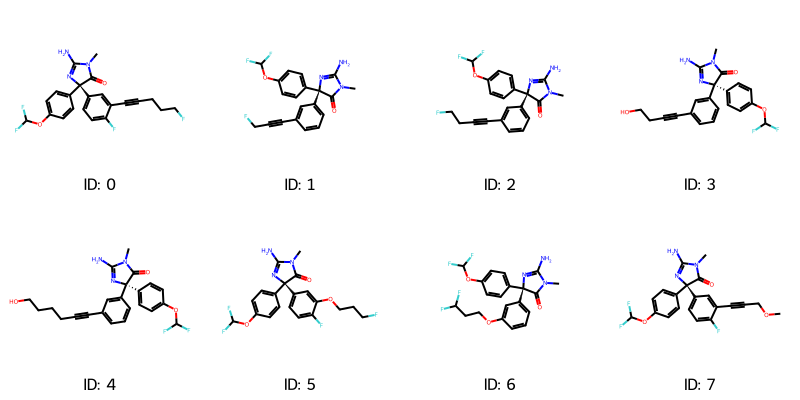

In [2]:
import numpy as np
import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Draw

#Load data using Morgan Fingerprints
tasks, datasets, transformers = dc.molnet.load_bace_classification(
    featurizer='ECFP',
    splitter='scaffold'
)
train, valid, test = datasets

#Check the class balance
print(f"Percentage of active inhibitors: {train.y.mean() * 100:.2f}%")

# Extract SMILES from the dataset metadata and visualize some of the inhibitors
smiles_list = train.ids[:8]
mols = [Chem.MolFromSmiles(s) for s in smiles_list]
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=[f"ID: {i}" for i in range(8)])
img

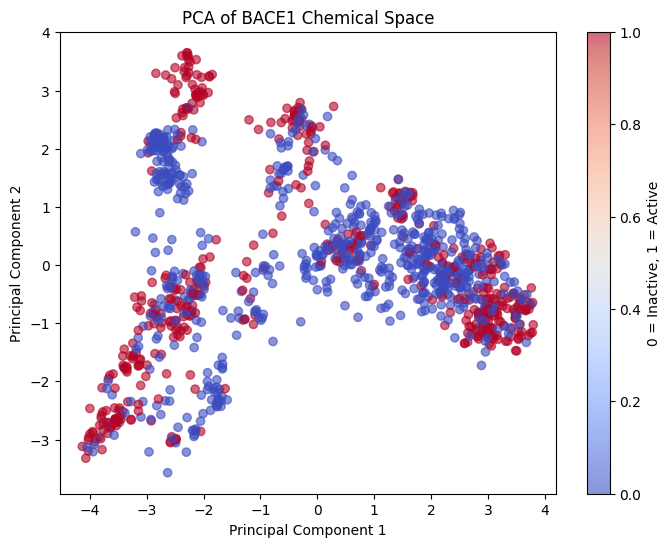

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce the 1024-bit fingerprint to 2 dimensions
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(train.X)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=train.y.ravel(), cmap='coolwarm', alpha=0.6)
plt.colorbar(label='0 = Inactive, 1 = Active')
plt.title('PCA of BACE1 Chemical Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

#Train baseline logistic regression
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(train.X, train.y.ravel())

#Predict probabilities on the test set
test_probs = baseline_model.predict_proba(test.X)[:, 1]

#Calculate ROC-AUC
score = roc_auc_score(test.y, test_probs)
print(f"Baseline Test ROC-AUC Score: {score:.4f}")

Baseline Test ROC-AUC Score: 0.8112


In [78]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Initialize Neural Network (Multi-Layer Perceptron)
# We use two hidden layers (144 and 72 neurons), alpha adjusted to 0.01, early stopping
nn_model = MLPClassifier(solver = 'adam', hidden_layer_sizes=(144,72), alpha = 0.01, max_iter=500, learning_rate_init= 0.001, early_stopping=True)

# Train the model
nn_model.fit(train.X, train.y.ravel())

# Get predictions for the test set
nn_probs = nn_model.predict_proba(test.X)[:, 1]
nn_preds = nn_model.predict(test.X)

# Check Performance
print(f"Neural Network Test ROC-AUC: {roc_auc_score(test.y, nn_probs):.4f}")

# Get the probabilities
probs = nn_model.predict_proba(test.X)[:, 1]

# Pick a threshold for weighting (L2 regularization)
threshold = 0.15
final_preds = (probs > threshold).astype(int)

Neural Network Test ROC-AUC: 0.8085


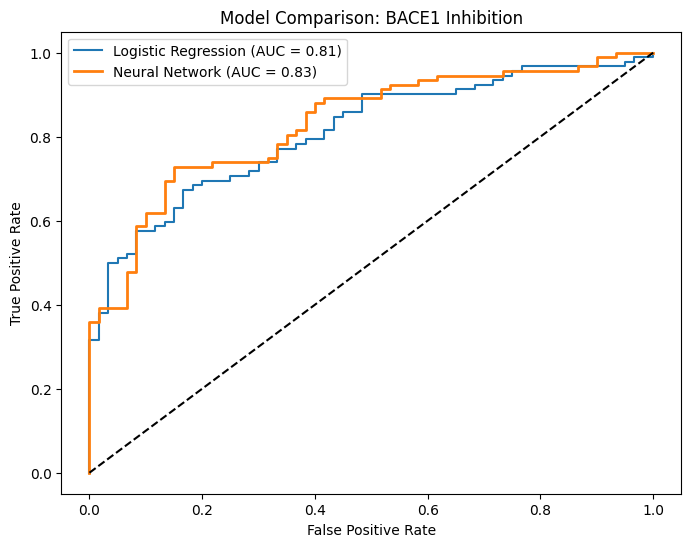

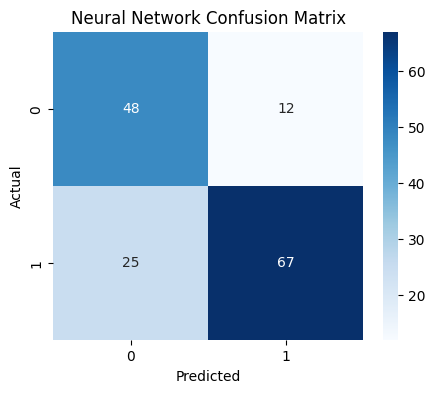

In [52]:
import seaborn as sns

# 1. Comparison ROC Curve
fpr_log, tpr_log, _ = roc_curve(test.y, test_probs) # from our baseline
fpr_nn, tpr_nn, _ = roc_curve(test.y, nn_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc(fpr_log, tpr_log):.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc(fpr_nn, tpr_nn):.2f})', lw=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison: BACE1 Inhibition')
plt.legend()
plt.show()

# 2. Confusion Matrix for the NN
cm = confusion_matrix(test.y, final_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()
